<a href="https://colab.research.google.com/github/Peddineni-Sowjanya/Blood-group-detection-using-fingerprint/blob/main/Layer_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/abhiramshibaraya/fingerprint-based-blood-group-detection
License(s): CC-BY-NC-SA-4.0
Dataset Extracted!
Loaded 8000 images from 8 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.3621 - loss: 1.8568 - val_accuracy: 0.7215 - val_loss: 0.7206
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.7796 - loss: 0.5831 - val_accuracy: 0.8435 - val_loss: 0.4047
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8383 - loss: 0.4343 - val_accuracy: 0.8645 - val_loss: 0.3479
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8643 - loss: 0.3783 - val_accuracy: 0.8720 - val_loss: 0.3362
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8739 - loss: 0.3252 - val_accuracy: 0.8705 - val_loss: 0.3525
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8996 - loss: 0.2693 - val_accuracy: 0.8980 - val_loss: 0.2767
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9051 - loss: 0.2411 - val_accuracy: 0.8875 - val_loss: 0.3017
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9403 - loss: 0.1830 - val_a

<Figure size 1000x600 with 0 Axes>

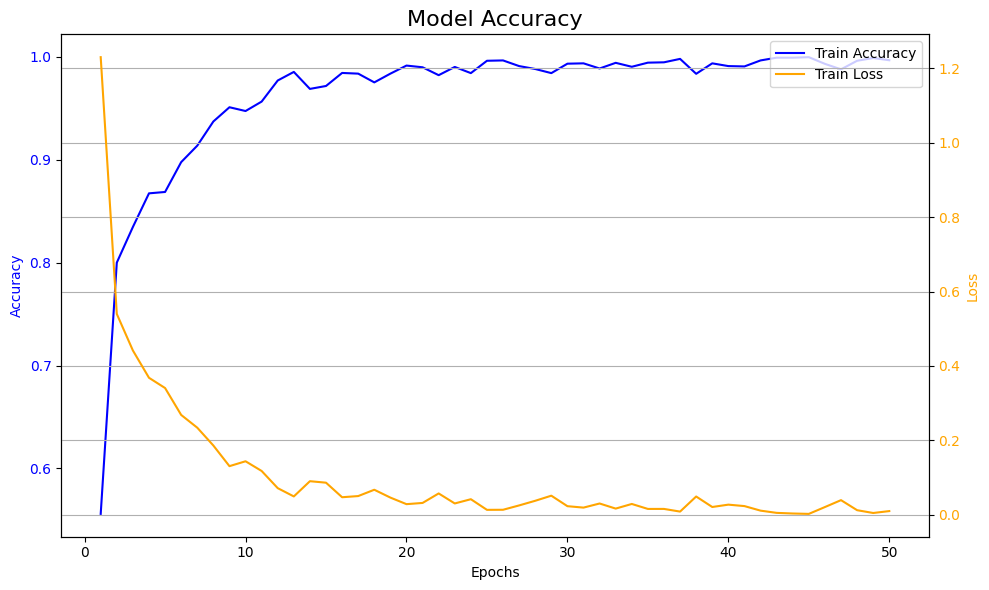

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


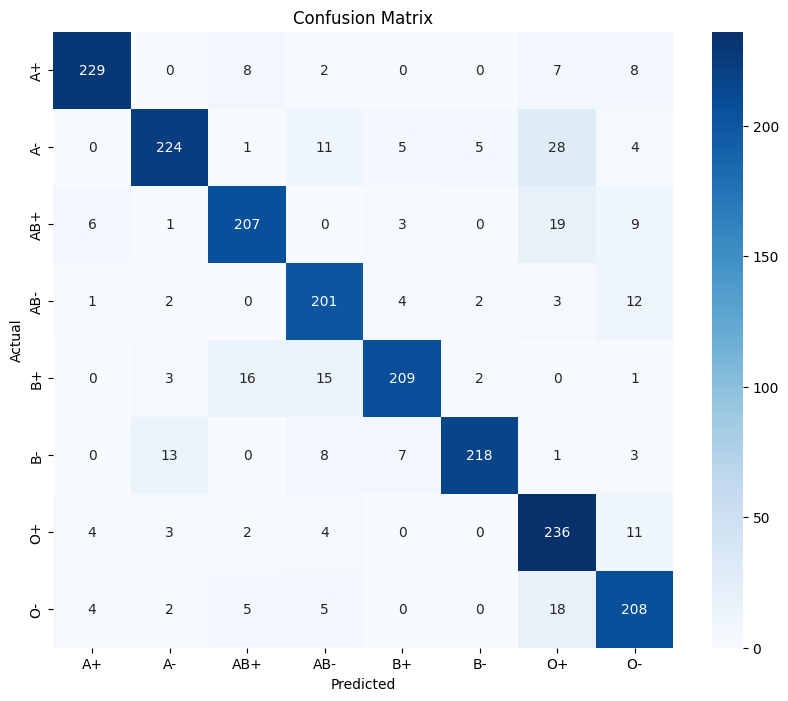


Classification Report:
               precision    recall  f1-score   support

          A+       0.94      0.90      0.92       254
          A-       0.90      0.81      0.85       278
         AB+       0.87      0.84      0.86       245
         AB-       0.82      0.89      0.85       225
          B+       0.92      0.85      0.88       246
          B-       0.96      0.87      0.91       250
          O+       0.76      0.91      0.83       260
          O-       0.81      0.86      0.84       242

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000

Model saved successfully!


In [1]:
# STEP 1: Setup
!pip install -q kaggle
from google.colab import files
files.upload()  # Upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d abhiramshibaraya/fingerprint-based-blood-group-detection

from zipfile import ZipFile
with ZipFile("/content/fingerprint-based-blood-group-detection.zip", 'r') as zip:
    zip.extractall()
print("Dataset Extracted!")

# STEP 2: Data Loading
import os
import cv2
import numpy as np
from tensorflow.keras.utils import to_categorical

def load_dataset(dataset_path, img_size=(128, 128)):
    X, y = [], []
    label_map = {}
    class_id = 0

    for blood_group in sorted(os.listdir(dataset_path)):
        group_path = os.path.join(dataset_path, blood_group)
        if not os.path.isdir(group_path): continue
        label_map[class_id] = blood_group
        for img_name in os.listdir(group_path):
            img_path = os.path.join(group_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None: continue
            img = cv2.resize(img, img_size)
            X.append(img)
            y.append(class_id)
        class_id += 1

    X = np.array(X).reshape(-1, img_size[0], img_size[1], 1) / 255.0
    y = to_categorical(np.array(y), num_classes=len(label_map))
    return X, y, label_map

dataset_path = "/content/dataset"
X, y, label_map = load_dataset(dataset_path)
print(f"Loaded {X.shape[0]} images from {len(label_map)} classes.")

# STEP 3: Model Building with Layer Normalization
import tensorflow as tf
from tensorflow.keras import layers, models

def build_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.LayerNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.LayerNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.LayerNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.LayerNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

input_shape = (128, 128, 1)
num_classes = len(label_map)
model = build_model(input_shape, num_classes)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# STEP 4: Train/Test Split
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)

# STEP 5: Training
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_val, y_val))

# STEP 6: Evaluation
val_loss, val_accuracy = model.evaluate(X_val, y_val)
print(f"Validation Accuracy: {val_accuracy*100:.2f}%")

# STEP 7: Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
epochs = range(1, len(history.history['accuracy']) + 1)

# Plot accuracy (left y-axis)
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_title("Model Accuracy", fontsize=16)
ax1.plot(epochs, history.history['accuracy'], 'b-', label='Train Accuracy')
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Accuracy", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Plot loss (right y-axis)
ax2 = ax1.twinx()
ax2.plot(epochs, history.history['loss'], 'orange', label='Train Loss')
ax2.set_ylabel("Loss", color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Add legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.grid(True)
plt.tight_layout()
plt.show()


# STEP 8: Confusion Matrix
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true = np.argmax(y_val, axis=1)
y_pred = np.argmax(model.predict(X_val), axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_map.values(), yticklabels=label_map.values())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=label_map.values()))

# STEP 9: Save Model
model.save("blood_group_cnn_model_v2.h5")
print("Model saved successfully!")
